In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install pytorch-tabnet torch

In [3]:
!pip install catboost lightgbm pytorch-tabnet

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from pytorch_tabnet.tab_model import TabNetRegressor

# 設定資料路徑
DATA_PATH = "/content/drive/MyDrive/SideProject/用機器學習預測台灣珊瑚礁覆蓋面積/珊瑚礁/ReefCheckTaiwan_2009_2020_data.csv"
SITE_PATH = "/content/drive/MyDrive/SideProject/用機器學習預測台灣珊瑚礁覆蓋面積/珊瑚礁/ReefCheckTaiwan_2009_2020_site.csv"

In [31]:
data = pd.read_csv(DATA_PATH)
data_site = pd.read_csv(SITE_PATH)

# 選擇特徵
selected_columns = [
    'Date', 'Site', 'HC', 'SC', 'RKC', 'NIA', 'SP', 'Butterflyfish',
    'Haemulidae', 'Snapper', 'BarramundiCod', 'HumpheadWrasse',
    'BumpheadParrotfish', 'Parrotfish', 'MoralEel', 'Grouper_XS',
    'Grouper_S', 'Grouper_M', 'Grouper_L', 'Total_fish',
    'BandedCoralShrimp', 'Diadema', 'PencilUrchin', 'CollectorUrchin',
    'SeaCucumber', 'COTS', 'Triton', 'Lobster', 'GiantClam_XS',
    'GiantClam_S', 'GiantClam_M', 'GiantClam_L', 'GiantClam_XL',
    'GiantClam_XXL'
]
df = data[selected_columns].copy()

# 合併經緯度資訊
site_info = data_site[['Site', 'Latitude', 'Longitude']]
df = pd.merge(df, site_info, on='Site', how='left')

# 處理時間與缺失值
df['Date'] = pd.to_datetime(df['Date'], format='%Y%m%d', errors='coerce')
df.dropna(subset=['Latitude', 'Longitude', 'Date'], inplace=True)
df['Year'] = df['Date'].dt.year

In [32]:
data

,Unit,Site,Region,Date,Depth_cate,HC,SC,RKC,NIA,SP,...,GiantClam_L,GiantClam_XL,GiantClam_XXL,Total_invert,Damage_boat,Damage_dynamite,Damage_other,Trash_fishery,Trash_general,Impact_level
0,YeLiu_090613_s_1,YeLiu,Northeast coast,20090613,Shallow,0.100,0.275,0.0,0.0,0.00,...,0,0,0,0,0,0,0,2,2.0,Medium
1,YeLiu_090613_s_2,YeLiu,Northeast coast,20090613,Shallow,0.075,0.250,0.0,0.0,0.00,...,0,0,0,0,0,0,0,2,2.0,Medium
2,YeLiu_090613_s_3,YeLiu,Northeast coast,20090613,Shallow,0.175,0.350,0.0,0.0,0.00,...,0,0,0,0,0,0,0,1,1.0,Medium
3,YeLiu_090613_s_4,YeLiu,Northeast coast,20090613,Shallow,0.075,0.450,0.0,0.0,0.00,...,0,0,0,9,0,0,0,1,0.0,Low
4,YeLiu_100704_s_1,YeLiu,Northeast coast,20100704,Shallow,0.475,0.150,0.0,0.0,0.00,...,0,0,0,0,0,0,0,2,0.0,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1386,EasternIsletW_200615_s_3,EasternIsletW,Southern Islands,20200615,Shallow,0.575,0.050,0.0,0.0,0.00,...,0,0,0,1,0,0,0,2,0.0,Medium
1387,EasternIsletE_200615_s_1,EasternIsletE,Southern Islands,20200615,Shallow,0.525,0.100,0.0,0.0,0.00,...,0,0,0,6,0,0,0,2,1.0,Medium
1388,EasternIsletE_200615_s_2,EasternIsletE,Southern Islands,20200615,Shallow,0.400,0.025,0.0,0.0,0.05,...,0,0,0,4,0,0,0,4,0.0,Medium
1389,EasternIsletE_200615_s_3,EasternIsletE,Southern Islands,20200615,Shallow,0.775,0.000,0.0,0.0,0.00,...,0,0,0,1,0,0,0,2,0.0,Medium


In [33]:
print(data['Site'].unique())

['YeLiu' 'TidalPark' 'FanCaiao' 'BiTou' 'LongDong1.5' 'LongDong4'
 'ShiTiPing' 'GiHaw' 'ShanYuan' 'HeChei' 'ChaiKou' 'GongGuan'
 'JiangJunYan' 'DaBaiSha' 'ShiLang' 'TurtleBay' 'BeautyRock' 'HenRock'
 'LionSouth' 'HouShi' 'BeautyCave' 'YuChenWei' 'EasternIsletS'
 'EasternIsletE' 'EasternIsletW']


In [34]:
# 建立地區座標對照表
site_coords = {
    # 東北角海域
    'YeLiu': [25.21, 121.69], 'TidalPark': [25.14, 121.78], 'FanCaiao': [25.13, 121.82],
    'BiTou': [25.12, 121.91], 'LongDong1.5': [25.11, 121.91], 'LongDong4': [25.10, 121.92],
    # 東部海域
    'ShiTiPing': [23.48, 121.51], 'GiHaw': [23.11, 121.39], 'ShanYuan': [22.82, 121.19], 'HeChei': [22.81, 121.20],
    # 綠島 (Green Island)
    'ChaiKou': [22.68, 121.48], 'GongGuan': [22.68, 121.50], 'JiangJunYan': [22.68, 121.50],
    'DaBaiSha': [22.64, 121.48], 'ShiLang': [22.66, 121.47],
    # 小琉球 (Xiao Liu Qiu)
    'TurtleBay': [22.33, 120.35], 'BeautyRock': [22.35, 120.37], 'HenRock': [22.33, 120.37],
    'LionSouth': [22.34, 120.37], 'HouShi': [22.32, 120.36], 'BeautyCave': [22.35, 120.36], 'YuChenWei': [22.35, 120.38],
    # 東嶼坪 (Eastern Islet - 南方四島)
    'EasternIsletS': [23.25, 119.51], 'EasternIsletE': [23.26, 119.52], 'EasternIsletW': [23.25, 119.50]
}

# 將座標對應回您的 dataframe
# 假設您的主 DataFrame 叫 df
df['lat'] = df['Site'].map(lambda x: site_coords.get(x, [None, None])[0])
df['lon'] = df['Site'].map(lambda x: site_coords.get(x, [None, None])[1])

In [35]:
import requests
import pandas as pd
import numpy as np
from datetime import timedelta
import time

def get_climate_open_meteo(df):
    unique_surveys = df[['Site', 'Date']].drop_duplicates().copy()
    avg_temps = []
    total_rains = []

    print(f"📡 正在從 Open-Meteo 抓取 {len(unique_surveys)} 筆氣候資料...")

    for idx, row in unique_surveys.iterrows():
        site = row['Site']
        end_date = row['Date']
        start_date = end_date - timedelta(days=30)

        lat, lon = site_coords.get(site, [None, None])
        if lat is None:
            avg_temps.append(np.nan); total_rains.append(np.nan)
            continue

        # Open-Meteo 格式: YYYY-MM-DD
        s_str = start_date.strftime('%Y-%m-%d')
        e_str = end_date.strftime('%Y-%m-%d')

        # 使用 Open-Meteo 歷史/存檔 API
        url = f"https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date={s_str}&end_date={e_str}&daily=temperature_2m_mean,precipitation_sum&timezone=GMT"

        try:
            response = requests.get(url, timeout=10)
            if response.status_code == 200:
                res = response.json()
                temp_list = res['daily']['temperature_2m_mean']
                rain_list = res['daily']['precipitation_sum']

                # 清洗 None 值（API 有時會回傳 null）
                temp_list = [t for t in temp_list if t is not None]
                rain_list = [r for r in rain_list if r is not None]

                avg_temps.append(np.mean(temp_list) if temp_list else np.nan)
                total_rains.append(np.sum(rain_list) if rain_list else np.nan)
                print(f"✅ {site} ({e_str}) 抓取成功")
            else:
                print(f"❌ {site} 失敗: 狀態碼 {response.status_code}")
                avg_temps.append(np.nan); total_rains.append(np.nan)
        except:
            print(f"⚠️ {site} 連線異常")
            avg_temps.append(np.nan); total_rains.append(np.nan)

        time.sleep(0.2) # Open-Meteo 速度很快，不需要等太久

    unique_surveys['Avg_Temp_30d'] = avg_temps
    unique_surveys['Total_Rain_30d'] = total_rains
    return df.merge(unique_surveys, on=['Site', 'Date'], how='left')

# 執行抓取
data_with_weather = get_climate_open_meteo(df)

# 顯示前幾筆確認
print("\n--- 抓取結果預覽 ---")
print(data_with_weather[['Site', 'Date', 'Avg_Temp_30d', 'Total_Rain_30d']].dropna().head())

📡 正在從 Open-Meteo 抓取 178 筆氣候資料...
✅ YeLiu (2009-06-13) 抓取成功
✅ YeLiu (2010-07-04) 抓取成功
✅ YeLiu (2011-08-21) 抓取成功
✅ YeLiu (2012-07-01) 抓取成功
✅ YeLiu (2013-09-15) 抓取成功
✅ YeLiu (2014-08-17) 抓取成功
✅ YeLiu (2015-08-16) 抓取成功
✅ YeLiu (2016-05-15) 抓取成功
✅ YeLiu (2016-08-13) 抓取成功
✅ YeLiu (2017-08-13) 抓取成功
✅ YeLiu (2018-05-20) 抓取成功
✅ YeLiu (2019-05-12) 抓取成功
✅ YeLiu (2020-07-11) 抓取成功
✅ TidalPark (2017-08-19) 抓取成功
✅ TidalPark (2018-08-19) 抓取成功
✅ TidalPark (2019-06-02) 抓取成功
✅ TidalPark (2020-06-27) 抓取成功
✅ FanCaiao (2009-06-13) 抓取成功
✅ FanCaiao (2010-07-17) 抓取成功
✅ FanCaiao (2011-08-20) 抓取成功
✅ FanCaiao (2012-06-09) 抓取成功
✅ FanCaiao (2013-07-28) 抓取成功
✅ FanCaiao (2014-07-05) 抓取成功
✅ FanCaiao (2015-09-23) 抓取成功
✅ FanCaiao (2016-05-29) 抓取成功
✅ FanCaiao (2017-07-01) 抓取成功
✅ FanCaiao (2018-07-07) 抓取成功
✅ FanCaiao (2019-07-10) 抓取成功
✅ FanCaiao (2020-07-25) 抓取成功
✅ BiTou (2009-05-23) 抓取成功
✅ BiTou (2010-07-11) 抓取成功
✅ BiTou (2011-08-14) 抓取成功
✅ BiTou (2012-07-28) 抓取成功
✅ BiTou (2013-07-27) 抓取成功
✅ BiTou (2014-06-14) 抓取成功
✅ BiT

In [37]:
# 定義目標變數 (y = HC + SC + RKC) 並移除不必要欄位
y = df['HC'] + df['SC'] + df['RKC']
new_features = ['Avg_Temp_30d', 'Total_Rain_30d']
current_features = [col for col in data_with_weather.columns if col not in ['HC', 'SC', 'RKC', 'Site', 'Date']]

# 處理遺失值 (填補平均值，避免模型報錯)
data_with_weather['Avg_Temp_30d'] = data_with_weather['Avg_Temp_30d'].fillna(data_with_weather['Avg_Temp_30d'].mean())
data_with_weather['Total_Rain_30d'] = data_with_weather['Total_Rain_30d'].fillna(data_with_weather['Total_Rain_30d'].mean())

# 更新 X 和 y
X = data_with_weather[current_features]

# 分割與標準化
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

In [38]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"R2 : {r2:.4f}\n")
    return mae, mse, r2

def plot_results(y_true, y_pred, title):
    plt.figure(figsize=(10, 5))
    sns.lineplot(x=range(len(y_true)), y=y_true, label='Actual', alpha=0.6)
    sns.lineplot(x=range(len(y_pred)), y=y_pred, label='Predicted', alpha=0.6)
    plt.title(title)
    plt.legend()
    plt.show()

In [42]:
import torch
from pytorch_tabnet.pretraining import TabNetPretrainer
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.model_selection import GridSearchCV

# 1. 執行自監督預訓練 (Self-supervised Pre-training)
# 這對應你圖片中的 Masking 與 Reconstruction 過程
unsupervised_model = TabNetPretrainer(
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    mask_type='sparsemax',
    seed=42
)

unsupervised_model.fit(
    X_train=X_train_scaled.values,
    eval_set=[X_test_scaled.values],
    max_epochs=100,
    patience=10,
    batch_size=128,
    virtual_batch_size=16,
    pretraining_ratio=0.8 # 遮蓋 90% 的特徵來讓模型練習預測
)


# 2. 設定 Grid Search 參數
param_grid_tabnet = {
    'n_d': [4, 8],
    'n_a': [4, 8],
    'n_steps': [2, 3],
    'gamma': [1.3, 1.5],
    'lambda_sparse': [1e-1, 1e-2],
    'momentum': [0.02, 0.05],
    'n_shared': [2],
    'n_independent': [2],

}

# 3. 定義 Grid Search
# 注意：我們在初始化 TabNetRegressor 時不直接傳入 pretrainer，
# 而是在 fit 的時候傳入
grid_tabnet = GridSearchCV(
    TabNetRegressor(verbose=0, seed=42),
    param_grid_tabnet,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=1  # 使用預訓練模型時，建議設為 1 以確保權重正確載入且避免顯存問題
)

# 4. 執行 fit (整合預訓練模型)
# 這裡使用 fit_params 將自監督學習的成果從 best_estimator 傳下去
grid_tabnet.fit(
    X_train_scaled.values,
    y_train.values.reshape(-1, 1),
    max_epochs=100,
    patience=10,
    batch_size=128,
    virtual_batch_size=16,
    from_unsupervised=unsupervised_model # 關鍵：將第一步學到的「特徵直覺」傳給 Regressor
)

# 5. 預測
y_pred_tabnet = grid_tabnet.best_estimator_.predict(X_test_scaled.values).flatten()

print(f"最佳參數: {grid_tabnet.best_params_}")

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: -7.8172 | val_0_unsup_loss_numpy: 3910974308352.0|  0:00:00s
epoch 1  | loss: -35.94052| val_0_unsup_loss_numpy: 30304299384832.0|  0:00:00s
epoch 2  | loss: -100.7442| val_0_unsup_loss_numpy: 108923726069760.0|  0:00:00s
epoch 3  | loss: -170.10669| val_0_unsup_loss_numpy: 170411081859072.0|  0:00:01s
epoch 4  | loss: -409.51301| val_0_unsup_loss_numpy: 178085047566336.0|  0:00:01s
epoch 5  | loss: -673.54018| val_0_unsup_loss_numpy: 166051572613120.0|  0:00:01s
epoch 6  | loss: -1390.92239| val_0_unsup_loss_numpy: 33544856403968.0|  0:00:02s
epoch 7  | loss: -1619.64145| val_0_unsup_loss_numpy: 57552368828416.0|  0:00:02s
epoch 8  | loss: -2563.17554| val_0_unsup_loss_numpy: 157328343040000.0|  0:00:02s
epoch 9  | loss: -3888.73152| val_0_unsup_loss_numpy: 426967060971520.0|  0:00:03s
epoch 10 | loss: -4524.64557| val_0_unsup_loss_numpy: 765220230266880.0|  0:00:03s

Early stopping occurred at epoch 10 with best_epoch = 0 and best_val_0_unsup_loss_numpy = 39109743083

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:118: UserWarning: Pretraining: n_a changed from 4 to 8
  warnings.warn(wrn_msg)
/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:118: UserWarning: Pretraining: n_d changed from 4 to 8
  warnings.warn(wrn_msg)
/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:118: UserWarning: Pretraining: n_steps changed from 2 to 3
  warnings.warn(wrn_msg)
/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)
/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:248: UserWarning: Loading weights from unsupervised pretraining
  warnings.warn("Loading weights from unsupervi

最佳參數: {'gamma': 1.3, 'lambda_sparse': 0.1, 'momentum': 0.02, 'n_a': 4, 'n_d': 4, 'n_independent': 2, 'n_shared': 2, 'n_steps': 2}


In [46]:
evaluate_model(y_test, y_pred_tabnet, "TabNet") #0.3856

--- TabNet ---
MAE: 0.1411
MSE: 0.0297
R2 : 0.3503



(0.14108955035191525, 0.029664889869270725, 0.35025187634097066)

In [39]:
from xgboost import XGBRegressor

param_grid_xgb = {
    'n_estimators': [100, 300],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 7],
    'subsample': [0.8, 0.9],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [0, 1],
    'min_child_weight': [3, 5]
}
grid_xgb = GridSearchCV(XGBRegressor(random_state=42), param_grid_xgb,
                        scoring='neg_mean_absolute_error', cv=3, n_jobs=-1)
grid_xgb.fit(X_train_scaled, y_train)
y_pred_xgb = grid_xgb.best_estimator_.predict(X_test_scaled)

evaluate_model(y_test, y_pred_xgb, "XGBoost") # 0.6120

--- XGBoost ---
MAE: 0.1040
MSE: 0.0177
R2 : 0.6120



(0.10401338689000887, 0.017715618966359474, 0.6119759677660533)

In [40]:
from catboost import CatBoostRegressor

param_grid_cat = {
    'iterations': [200, 500],
    'learning_rate': [0.03, 0.1],
    'depth': [4, 6],
    'random_strength': [1, 2]
}
grid_cat = GridSearchCV(CatBoostRegressor(verbose=0, random_seed=42, bootstrap_type='MVS'), param_grid_cat,
                        scoring='neg_mean_absolute_error', cv=3, n_jobs=-1)
grid_cat.fit(X_train_scaled, y_train)
y_pred_cat = grid_cat.best_estimator_.predict(X_test_scaled)

evaluate_model(y_test, y_pred_cat, "CatBoost") # 0.6189

--- CatBoost ---
MAE: 0.1042
MSE: 0.0174
R2 : 0.6189



(0.10418416528378731, 0.017397832642495836, 0.6189364206301913)

In [41]:
from lightgbm import LGBMRegressor

param_grid_lgbm = {
    'n_estimators': [100, 300],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [7, 15],
    'feature_fraction': [0.7, 0.8],
    'bagging_fraction': [0.7, 0.8],
    'boosting_type': ['gbdt', 'dart']
}
grid_lgbm = GridSearchCV(LGBMRegressor(random_state=42), param_grid_lgbm,
                         scoring='neg_mean_absolute_error', cv=3, n_jobs=-1)
grid_lgbm.fit(X_train_scaled, y_train)
y_pred_lgbm = grid_lgbm.best_estimator_.predict(X_test_scaled)

evaluate_model(y_test, y_pred_lgbm, "LightGBM") # 0.6110

[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000357 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 583
[LightGBM] [Info] Number of data points in the train set: 1049, number of used features: 24
[LightGBM] [Info] Start training from score 0.400381
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fra

(0.1048320285127271, 0.01776030213986441, 0.6109972751677695)

In [47]:
evaluate_model(y_test, y_pred_tabnet, "TabNet")
evaluate_model(y_test, y_pred_xgb, "XGBoost")
evaluate_model(y_test, y_pred_cat, "CatBoost")
evaluate_model(y_test, y_pred_lgbm, "LightGBM")

--- TabNet ---
MAE: 0.1411
MSE: 0.0297
R2 : 0.3503

--- XGBoost ---
MAE: 0.1040
MSE: 0.0177
R2 : 0.6120

--- CatBoost ---
MAE: 0.1042
MSE: 0.0174
R2 : 0.6189

--- LightGBM ---
MAE: 0.1048
MSE: 0.0178
R2 : 0.6110



(0.1048320285127271, 0.01776030213986441, 0.6109972751677695)

In [48]:
# 3. Meta-Learner (Ensemble)
meta_features = pd.DataFrame({'cat': y_pred_cat, 'lgbm': y_pred_lgbm, 'xgb': y_pred_xgb, 'tabnet' : y_pred_tabnet})
meta_learner = LinearRegression().fit(meta_features, y_test)
y_pred_ensemble = meta_learner.predict(meta_features)

In [49]:
evaluate_model(y_test, y_pred_ensemble, "Meta-Learner Ensemble")

--- Meta-Learner Ensemble ---
MAE: 0.1012
MSE: 0.0167
R2 : 0.6332



(0.10124550052974676, 0.016744985284425116, 0.6332356931982519)

/tmp/ipython-input-3387509764.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(15), x='Importance', y='Feature', ax=axes[i], palette='viridis')
/tmp/ipython-input-3387509764.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(15), x='Importance', y='Feature', ax=axes[i], palette='viridis')
/tmp/ipython-input-3387509764.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(15), x='Importance', y='Feature', ax=axes[i], palette='viridis')
/tmp/ipython-input-3387509764.py:29: FutureWarning: 

Passing `p

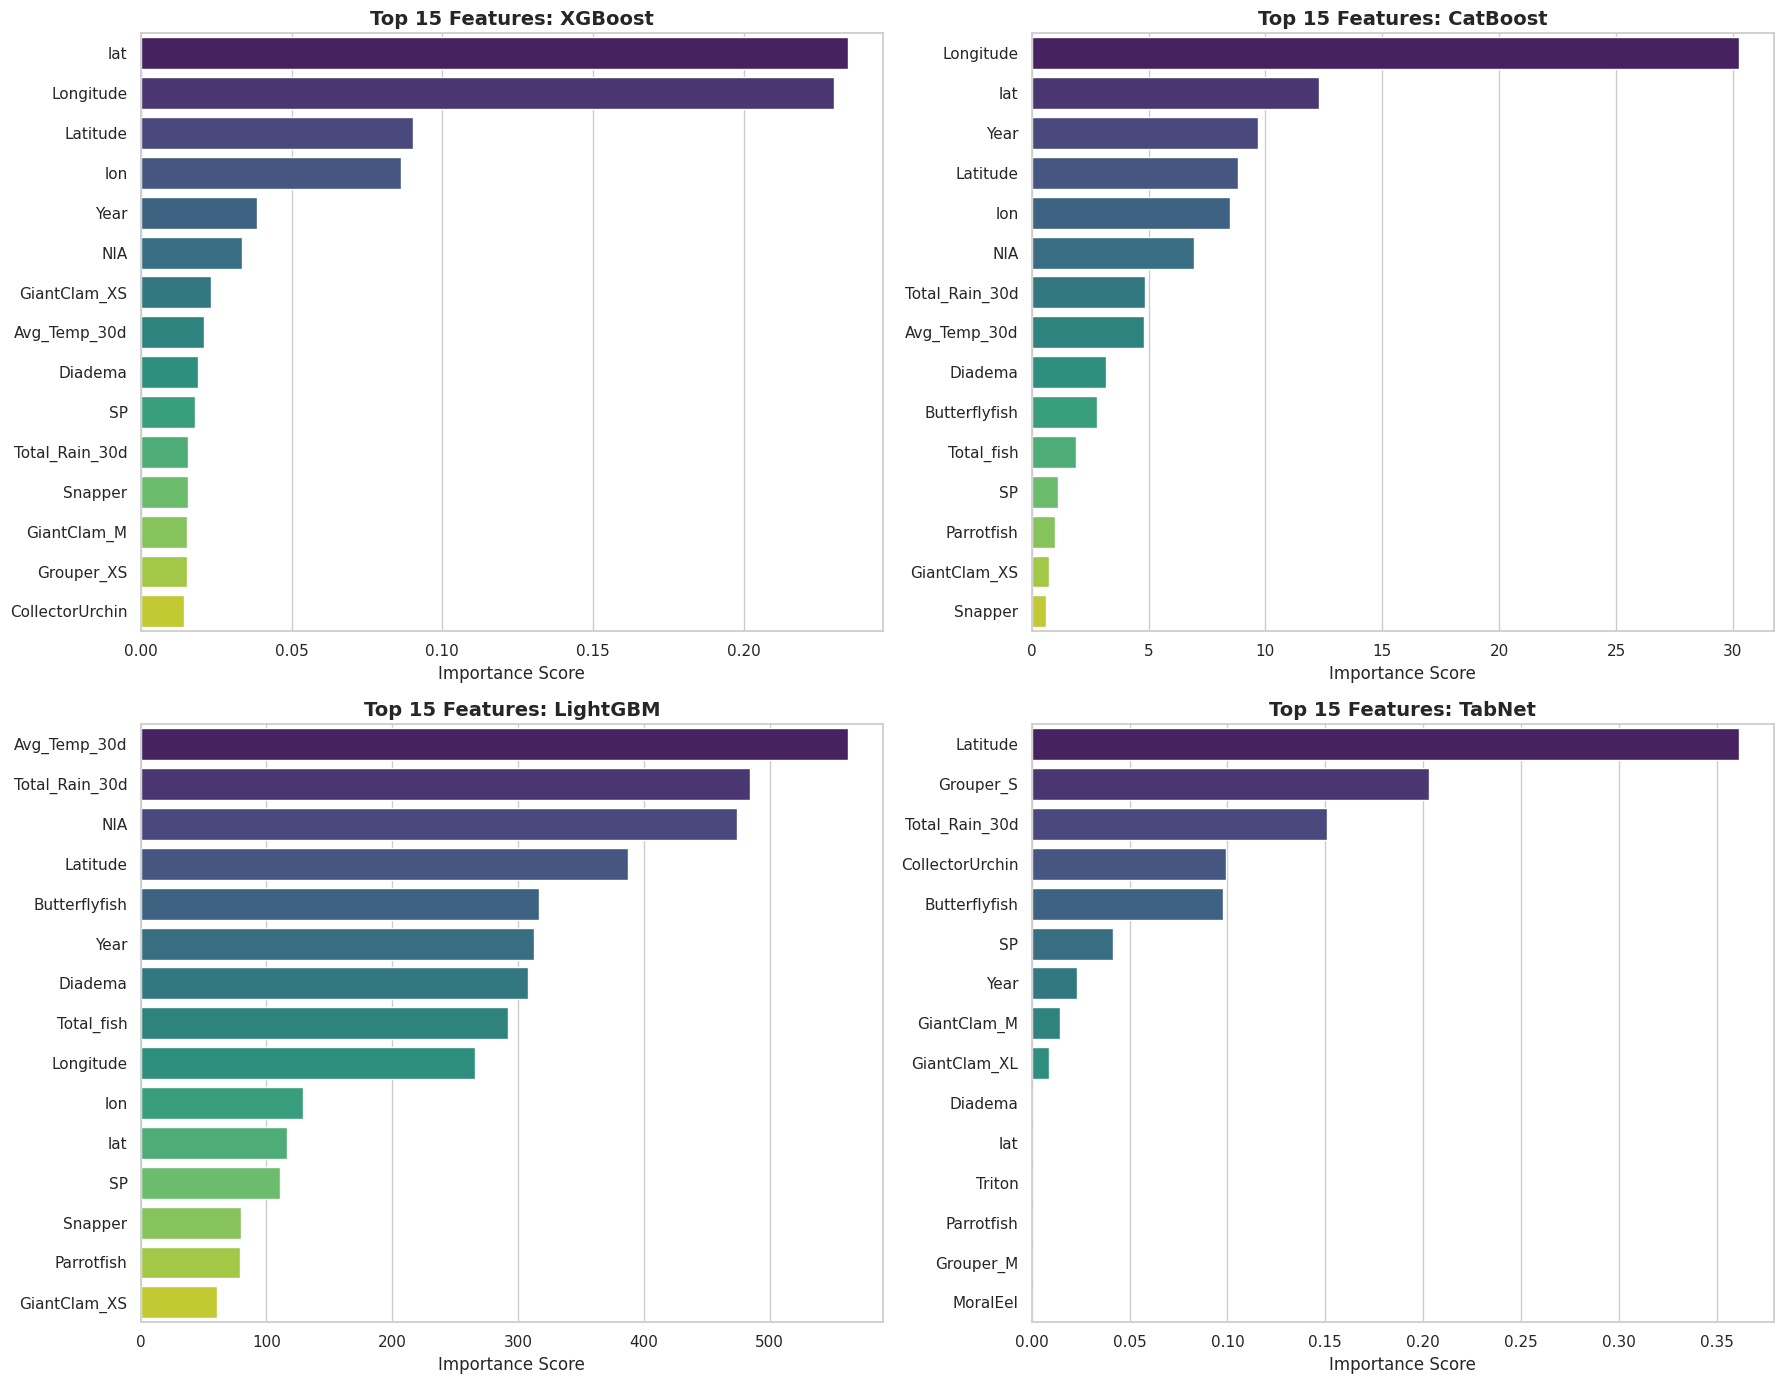

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_all_individual_importances(X_cols):
    # 定義模型清單與對應的提取方法
    models = {
        'XGBoost': grid_xgb.best_estimator_.feature_importances_,
        'CatBoost': grid_cat.best_estimator_.get_feature_importance(),
        'LightGBM': grid_lgbm.best_estimator_.feature_importances_,
        'TabNet': grid_tabnet.best_estimator_.feature_importances_
    }

    # 設定繪圖風格
    sns.set_theme(style="whitegrid")

    # 建立 2x2 的子圖佈局
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    axes = axes.flatten()

    for i, (name, importance) in enumerate(models.items()):
        # 建立該模型的 DataFrame 並排序
        df = pd.DataFrame({
            'Feature': X_cols,
            'Importance': importance
        }).sort_values(by='Importance', ascending=False)

        # 繪製橫向長條圖
        sns.barplot(data=df.head(15), x='Importance', y='Feature', ax=axes[i], palette='viridis')

        axes[i].set_title(f'Top 15 Features: {name}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Importance Score')
        axes[i].set_ylabel('')

    plt.tight_layout()
    plt.show()

# 執行繪圖 (假設您的特徵矩陣變數名為 X)
plot_all_individual_importances(X.columns)

In [ ]:
# 假設你的 y_pred_ensemble 是最後的整合預測結果
# 假設你的 df_selected 是還沒 drop 'Site' 之前的完整 DataFrame

# 1. 建立結果對照表 (確保 Index 對齊)
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_ensemble
}, index=y_test.index)

# 2. 從原始資料中抓回 Site 和 Date 資訊
# 註：df_selected 是你在合併 Latitude/Longitude 後的那個 DataFrame
results_df['Site'] = data.loc[y_test.index, 'Site']
results_df['Date'] = pd.to_datetime(data.loc[y_test.index, 'Date'], format='%Y%m%d')

# 依日期排序，這樣折線圖才會按時間走
results_df = results_df.sort_values(by=['Site', 'Date'])

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_site_results(results_df, site_name):
    """
    指定地區畫出預測與實際值的對照圖
    """
    # 篩選特定地區
    site_data = results_df[results_df['Site'] == site_name]

    if site_data.empty:
        print(f"找不到地區: {site_name}，請檢查名稱是否正確。")
        return

    plt.figure(figsize=(12, 6))

    # 畫出實際值與預測值
    sns.lineplot(data=site_data, x='Date', y='Actual', label='Actual (HC+SC+RKC)', marker='o', linewidth=2)
    sns.lineplot(data=site_data, x='Date', y='Predicted', label='Predicted (Ensemble)', marker='x', linestyle='--', linewidth=2)

    plt.title(f'Prediction Performance at: {site_name}', fontsize=15)
    plt.xlabel('Survey Date', fontsize=12)
    plt.ylabel('Coral Cover (HC + SC + RKC)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 檢查一下有哪些地區可以選
print("可選地區列表:", results_df['Site'].unique())

In [ ]:
# 範例：查看 "綠島大香菇" 的結果 (請替換成你資料中實際有的 Site 名稱)
for i in range(len(results_df['Site'].unique())):
  target_site = results_df['Site'].unique()[i]
  plot_site_results(results_df, target_site)